In [3]:
# 1)
# Solving Systems of Linear Equations

# Import NumPy.
import numpy as np

# Create matrix of coefficients (A).
A = np.array([
    [27, -10, 4, -29],
    [-16, 5, -2, 18],
    [-17, 4, -2, 20],
    [-7, 2, -1, 8]
])

# Create matrix of values on the right side of equal sign (b).
b = np.array([
    [1],
    [-1],
    [0],
    [1]
])

# Solve the system of linear equations.
x_hat = np.linalg.inv(A.T @ A) @ A.T @ b

# Display results.
print(x_hat)


[[10.]
 [ 3.]
 [-9.]
 [ 7.]]


Part a: [[2.82842712]
 [0.        ]]


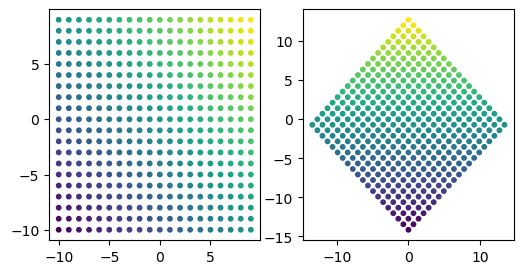

In [13]:
# 2
# Visualizing a Linear Transformation

# a)
# Create the transformation matrix (T).
A = np.array([
    [np.sqrt(2)/2, -np.sqrt(2)/2],
    [np.sqrt(2)/2, np.sqrt(2)/2]
])

# Create the input vector x.
x = np.array([
    [2],
    [-2]
])

# Apply the linear transformation.
Tx = A @ x
# Display results.
print(f'Part a: {Tx}')

# b)

# Import MatPlotLib
import matplotlib.pyplot as plt

# Create x and y values for grid.
x_grid = np.arange(-10, 10, 1)
y_grid = np.arange(-10, 10, 1)

# Create grid of points.
xx, yy = np.meshgrid(x_grid, y_grid)

# Plot the original grid of points.
# plt.scatter(xx, yy, s=20, c=xx+yy)

# Combine the x and y coordinates into a 2 x 400 matrix. 
xy = np.vstack([xx.flatten(), yy.flatten()])
xy.shape

# Apply the transformation to all points. 
trans = A @ xy
trans.shape

# Reshape the transformed coordinates.
xx_transformed = trans[0].reshape(xx.shape)
yy_transformed = trans[1].reshape(yy.shape)

# Plot the grid before and after.
f, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].scatter(xx, yy, s=10, c=xx+yy)
axes[1].scatter(xx_transformed, yy_transformed, s=10, c=xx+yy);

# c)
# The transformation matrix rotated the grid about the origin. 
# It did not undergo a change in size or shape, just orientation. 

In [23]:
# 3)
# Finding the Eigenvalues and Eigenvectors of a Matrix.

# a)

# Create the matrix (A).
A = np.array([
    [4, 0, 1],
    [-1, -6, -2],
    [5, 0, 0]
])

# Create the vector (v1).
v1 = np.array([
    [1],
    [2],
    [3]
])

# Calculate A times v1.
Av_1 = A @ v1

# Display answer.
print('Part a:')
print(Av_1)
print('The vector created from this problem is not an eigenvector of A'
      ' because it is not a scalar multiple of the original vector.')

# b)

# Create the vector (v2).
v2 = np.array([
    [0],
    [1],
    [0]
])

# Calculate A times v2.
Av_2 = A @ v2

# Display answer.
print('Part b:')
print(Av_2)
print('The vector created from this problem is an eigenvector of A'
      ' because Av = -6v.')

# c)

# Find all eigenvalues and eigenvectors of A.
eigvals, eigvecs = np.linalg.eig(A)

# Display results
print('Eigenvalues:')
print(eigvals)
print('Eigenvectors:')
print(eigvecs)

Part a:
[[  7]
 [-19]
 [  5]]
The vector created from this problem is not an eigenvector of A because it is not a scalar multiple of the original vector.
Part b:
[[ 0]
 [-6]
 [ 0]]
The vector created from this problem is an eigenvector of A because Av = -6v.
Eigenvalues:
[-6.  5. -1.]
Eigenvectors:
[[ 0.          0.69431384 -0.18493168]
 [ 1.         -0.18935832 -0.33287702]
 [ 0.          0.69431384  0.9246584 ]]


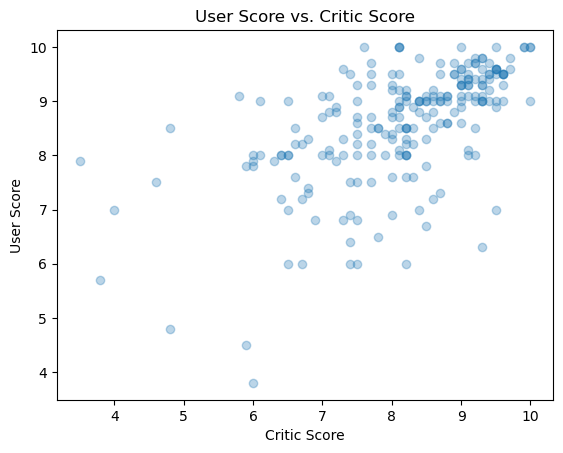

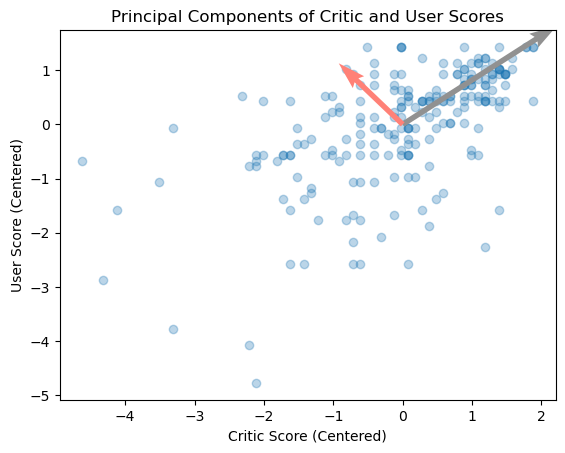

In [45]:
# 4) a & b
# Principal Component Analysis

# Import pandas.
import pandas as pd

# Load the dataset. 
data_vg = pd.read_csv("vgsales-12-4-2019.csv")

# Remove missing values.;/
data_vg = data_vg[["User_Score", "Critic_Score"]].dropna()

# Create the scatterplot.
plt.scatter(data_vg["Critic_Score"],
            data_vg["User_Score"],
            alpha=0.3)
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("User Score vs. Critic Score")
plt.show()

# Create data matrix with the two variables.
X = np.array([data_vg["Critic_Score"],
              data_vg["User_Score"]]).T

# Comput the covariance matrix of the dataset.
C = np.cov(X, rowvar=False)

# Calculate the eigenvectors and eigenvalues.
eigvals, eigvecs = np.linalg.eig(C)
eigvals, eigvecs

# Store eigenvectors as vectors u and v. 
u = eigvecs[:, 0].reshape(-1, 1)
v = eigvecs[:, 1].reshape(-1, 1)

X_centered = X - X.mean(axis=0)

plt.quiver(0, 0, 
           2 * np.sqrt(eigvals[0]) * u[0], 2 * np.sqrt(eigvals[0]) * u[1],
           color="#919191", angles='xy', scale_units='xy', scale=1,
           zorder=2, width=0.011)
plt.quiver(0, 0, 
           2 * np.sqrt(eigvals[1]) * v[0], 2 * np.sqrt(eigvals[1]) * v[1],
           color="#FF8177", angles='xy', scale_units='xy', scale=1,
           zorder=2, width=0.011)
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3)
plt.title("Principal Components of Critic and User Scores")
plt.xlabel("Critic Score (Centered)")
plt.ylabel("User Score (Centered)")
plt.show()
